# LangGraph Multi-Agent System for Data Science
## API Reference Notebook

This notebook documents the technical architecture of a stateful 
cyclic multi-agent system built with LangGraph and Llama 3.2.

### System Overview
- 5 nodes: Planner, EDA Analyst, ML Architect, Quality Reviewer, Report Writer
- Cyclic architecture with conditional routing
- Local LLM via Ollama (Llama 3.2)
- Benchmarked against: Single Agent, AutoGen, AutoGluon
- Tested on: Heart Disease, NYC Taxi, Amazon Reviews datasets

# All Imports 

In [1]:
from typing import TypedDict
import pandas as pd
import numpy as np
from langchain_ollama import OllamaLLM
from langgraph.graph import StateGraph, END
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score,
    precision_score, f1_score, roc_auc_score,
    classification_report
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
import shap
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports successful ")
llm = OllamaLLM(model="llama3.2")
print("LLM connected ")

All imports successful 
LLM connected 


# All Agents 

In [2]:
class AgentState(TypedDict):
    # Input
    raw_data: pd.DataFrame
    dataset_name: str
    
    # Planner outputs
    problem_type: str
    identified_risks: list
    strategy: str
    
    # EDA Analyst outputs
    cleaned_data: pd.DataFrame
    outlier_flags: dict
    class_distribution: dict
    eda_summary: str
    missing_value_report: dict
    
    # ML Architect outputs
    model_results: dict
    metrics: dict
    shap_values: object
    feature_importance: dict
    
    # Quality Reviewer outputs
    review_decision: str
    issues_found: list
    loop_count: int
    
    # Report Writer outputs
    final_report: str
    errors_caught: list

print("AgentState defined ")

AgentState defined 


# Planner node 

In [3]:
def planner_node(state: AgentState) -> AgentState:
    """
    Node 1: Planner
    - Analyzes raw dataset schema
    - Identifies problem type, risks, and strategy
    - Writes to state: problem_type, identified_risks, strategy
    """
    df = state["raw_data"]
    dataset_name = state["dataset_name"]
    
    # Analyze dataset
    n_rows, n_cols = df.shape
    dtypes = df.dtypes.to_dict()
    missing = df.isnull().sum().to_dict()
    
    # Build prompt for Llama
    prompt = f"""
    You are a data science planner. Analyze this dataset and respond in exactly this format:
    
    PROBLEM_TYPE: [classification or regression]
    RISKS: [comma separated list of risks from: imbalance, missing_values, noisy, multilingual, high_cardinality]
    STRATEGY: [one sentence strategy recommendation]
    
    Dataset: {dataset_name}
    Rows: {n_rows}
    Columns: {n_cols}
    Column types: {dtypes}
    Missing values: {missing}
    """
    
    response = llm.invoke(prompt)
    
    # Parse response
    lines = response.strip().split('\n')
    problem_type = "classification"
    identified_risks = []
    strategy = ""
    
    for line in lines:
        if "PROBLEM_TYPE:" in line:
            problem_type = line.split(":")[1].strip().lower()
        elif "RISKS:" in line:
            risks_str = line.split(":")[1].strip()
            identified_risks = [r.strip() for r in risks_str.split(",")]
        elif "STRATEGY:" in line:
            strategy = line.split(":")[1].strip()
    
    print(f" Planner complete")
    print(f"   Problem type: {problem_type}")
    print(f"   Risks identified: {identified_risks}")
    print(f"   Strategy: {strategy}")
    
    return {
        **state,
        "problem_type": problem_type,
        "identified_risks": identified_risks,
        "strategy": strategy
    }

print("Planner node defined ")

Planner node defined 


# EDA Analyst Node 

In [4]:
def eda_analyst_node(state: AgentState) -> AgentState:
    """
    Node 2: EDA Analyst
    - Cleans data based on planner's identified risks
    - Handles missing values, outliers
    - Generates visualizations
    - Writes to state: cleaned_data, outlier_flags, 
      class_distribution, eda_summary, missing_value_report
    """
    df = state["raw_data"].copy()
    risks = state["identified_risks"]
    dataset_name = state["dataset_name"]
    
    missing_value_report = {}
    outlier_flags = {}
    
    # Step 1: Handle missing values
    for col in df.columns:
        n_missing = df[col].isnull().sum()
        if n_missing > 0:
            missing_value_report[col] = int(n_missing)
            if df[col].dtype == 'object' or df[col].nunique() < 10:
                # Categorical — fill with mode
                df[col].fillna(df[col].mode()[0], inplace=True)
                print(f"   Filled {col} with mode: {df[col].mode()[0]}")
            else:
                # Continuous — fill with median
                df[col].fillna(df[col].median(), inplace=True)
                print(f"   Filled {col} with median: {df[col].median()}")
    
    # Step 2: Detect outliers using IQR
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
        if n_outliers > 0:
            outlier_flags[col] = {
                "count": n_outliers,
                "lower_bound": lower,
                "upper_bound": upper
            }
    
    # Step 3: Class distribution
    target_col = df.columns[-1]
    class_dist = df[target_col].value_counts().to_dict()
    class_dist_pct = (df[target_col].value_counts(normalize=True) * 100).to_dict()
    
    # Step 4: Visualizations
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Class distribution plot
    df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
    axes[0].set_title(f'{dataset_name} - Class Distribution')
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Count')
    
    # Correlation heatmap
    numeric_df = df.select_dtypes(include=[np.number])
    sns.heatmap(numeric_df.corr(), ax=axes[1], cmap='coolwarm', center=0)
    axes[1].set_title(f'{dataset_name} - Correlation Heatmap')
    
    plt.tight_layout()
    plt.savefig(f'{dataset_name}_eda.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Step 5: EDA summary via LLM
    prompt = f"""
    You are a data scientist. Summarize this EDA in 3 bullet points.
    
    Dataset: {dataset_name}
    Shape: {df.shape}
    Missing values found: {missing_value_report}
    Outliers detected: {outlier_flags}
    Class distribution: {class_dist_pct}
    
    Focus on what matters for model building.
    """
    eda_summary = llm.invoke(prompt)
    
    print(f" EDA Analyst complete")
    print(f"   Missing values handled: {missing_value_report}")
    print(f"   Outliers detected in: {list(outlier_flags.keys())}")
    print(f"   Class distribution: {class_dist_pct}")
    
    return {
        **state,
        "cleaned_data": df,
        "outlier_flags": outlier_flags,
        "class_distribution": class_dist_pct,
        "eda_summary": eda_summary,
        "missing_value_report": missing_value_report
    }

print("EDA Analyst node defined ")

EDA Analyst node defined 


# ML Architect Node 

In [5]:
def ml_architect_node(state: AgentState) -> AgentState:
    """
    Node 3: ML Architect
    - Trains multiple models on cleaned data
    - Computes full metrics including recall, F1, AUC
    - Generates SHAP values for explainability
    - Writes to state: model_results, metrics, 
      shap_values, feature_importance
    """
    df = state["cleaned_data"].copy()
    loop_count = state.get("loop_count", 0)
    issues = state.get("issues_found", [])
    
    # Identify target column
    target_col = df.columns[-1]
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    # Encode categoricals if needed
    le = LabelEncoder()
    for col in X.select_dtypes(include='object').columns:
        X[col] = le.fit_transform(X[col].astype(str))
    
    # If reviewer flagged imbalance — apply resampling on retry
    if loop_count > 0 and "low_recall" in issues:
        print("   Applying SMOTE-style resampling due to low recall...")
        df_majority = df[df[target_col] == 0]
        df_minority = df[df[target_col] == 1]
        df_minority_upsampled = resample(
            df_minority,
            replace=True,
            n_samples=len(df_majority),
            random_state=42
        )
        df_balanced = pd.concat([df_majority, df_minority_upsampled])
        X = df_balanced.drop(columns=[target_col])
        y = df_balanced[target_col]
        for col in X.select_dtypes(include='object').columns:
            X[col] = le.fit_transform(X[col].astype(str))
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Train multiple models
    models = {
        "random_forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "logistic_regression": LogisticRegression(max_iter=1000, random_state=42),
        "gradient_boosting": GradientBoostingClassifier(random_state=42)
    }
    
    best_model = None
    best_f1 = 0
    all_metrics = {}
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
        
        metrics = {
            "accuracy": round(accuracy_score(y_test, y_pred), 4),
            "recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
            "precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
            "f1": round(f1_score(y_test, y_pred, zero_division=0), 4),
            "auc": round(roc_auc_score(y_test, y_prob), 4) if y_prob is not None else None
        }
        all_metrics[name] = metrics
        
        if metrics["f1"] > best_f1:
            best_f1 = metrics["f1"]
            best_model = model
            best_model_name = name
    
    # SHAP values for best model
    explainer = shap.TreeExplainer(best_model) if hasattr(best_model, 'feature_importances_') else shap.LinearExplainer(best_model, X_train)
    shap_values = explainer.shap_values(X_test)
    
    # Feature importance
    if hasattr(best_model, 'feature_importances_'):
        feature_importance = dict(zip(X.columns, best_model.feature_importances_))
    else:
        feature_importance = dict(zip(X.columns, abs(best_model.coef_[0])))
    
    # Plot SHAP
    plt.figure(figsize=(10, 6))
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[1], X_test, show=False)
    else:
        shap.summary_plot(shap_values, X_test, show=False)
    plt.title(f'SHAP Values - {best_model_name}')
    plt.tight_layout()
    plt.savefig(f'{state["dataset_name"]}_shap.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print(f" ML Architect complete")
    print(f"   Best model: {best_model_name}")
    print(f"   Metrics: {all_metrics[best_model_name]}")
    
    return {
        **state,
        "model_results": {best_model_name: best_model},
        "metrics": all_metrics[best_model_name],
        "shap_values": shap_values,
        "feature_importance": feature_importance
    }

print("ML Architect node defined ")

ML Architect node defined 


# Quality Reviewer Node 

In [17]:
def quality_reviewer_node(state: AgentState) -> AgentState:
    """
    Node 4: Quality Reviewer — The Guardrail
    - Checks metrics for imbalance trap (low recall)
    - Checks data for impossible values
    - Checks SHAP consistency with EDA
    - Routes back to correct node or passes to report
    - Writes to state: review_decision, issues_found, loop_count
    """
    metrics = state["metrics"]
    outlier_flags = state["outlier_flags"]
    feature_importance = state["feature_importance"]
    loop_count = state.get("loop_count", 0)
    issues_found = []
    
    # Safety exit — max 3 loops
    if loop_count >= 3:
        print("Max loops reached — passing to report writer")
        return {
            **state,
            "review_decision": "pass",
            "issues_found": issues_found,
            "loop_count": loop_count
        }
    
    # Check 1: Low recall on imbalanced data
    recall = metrics.get("recall", 1.0)
    accuracy = metrics.get("accuracy", 1.0)
    if recall < 0.70 and accuracy > 0.75:
        issues_found.append("low_recall")
        print(f"   Low recall detected: {recall} — routing back to ML Architect")
    
    # Check 2: Impossible values still in data
    impossible_value_detected = False
    df = state["cleaned_data"]
    if "fare_amount" in df.columns:
        if (df["fare_amount"] < 0).any():
            issues_found.append("impossible_values")
            impossible_value_detected = True
            print("   Impossible values detected — routing back to EDA Analyst")
    
    # Check 3: SHAP consistency — only flag if top feature makes no sense
    top_shap_feature = max(feature_importance, key=feature_importance.get)
    top_shap_value = feature_importance[top_shap_feature]

    # Only flag if top feature importance is suspiciously uniform
    total_importance = sum(feature_importance.values())
    top_feature_ratio = top_shap_value / total_importance

    if top_feature_ratio > 0.95:
        issues_found.append("shap_mismatch")
        print(f"   SHAP dominated by single feature: {top_shap_feature}")
    else:
        print(f"    SHAP check passed: top feature = {top_shap_feature}")
        
    # Make routing decision
    if impossible_value_detected:
        decision = "retry_eda"
    elif "low_recall" in issues_found or "shap_mismatch" in issues_found:
        decision = "retry_ml"
    else:
        decision = "pass"
        print(" Quality Reviewer: All checks passed")
    
    # Ask LLM to validate decision
    prompt = f"""
    You are a senior data scientist reviewing model results.
    
    Metrics: {metrics}
    Issues found: {issues_found}
    Dataset: {state['dataset_name']}
    Loop count: {loop_count}
    
    Summarize the review in 2 sentences. Be specific about what passed and what failed.
    """
    review_summary = llm.invoke(prompt)
    print(f"\n   LLM Review: {review_summary}")
    
    return {
        **state,
        "review_decision": decision,
        "issues_found": issues_found,
        "loop_count": loop_count + 1,
        "errors_caught": state.get("errors_caught", []) + issues_found
    }

print("Quality Reviewer node defined ")

Quality Reviewer node defined 


# Report Writer Node 

In [18]:
def report_writer_node(state: AgentState) -> AgentState:
    """
    Node 5: Report Writer
    - Only runs when Quality Reviewer says PASS
    - Documents full journey including errors caught
    - Writes final benchmark report
    """
    prompt = f"""
    You are a data science report writer. Write a professional analysis report.
    
    Dataset: {state['dataset_name']}
    Problem Type: {state['problem_type']}
    
    EDA Summary:
    {state['eda_summary']}
    
    Final Model Metrics:
    {state['metrics']}
    
    Errors Caught by Reviewer:
    {state['errors_caught']}
    
    Number of Review Loops: {state['loop_count']}
    
    Feature Importance (top 5):
    {dict(sorted(state['feature_importance'].items(), key=lambda x: x[1], reverse=True)[:5])}
    
    Write the report with these sections:
    1. Executive Summary
    2. Data Quality Findings
    3. Model Performance
    4. Key Features Driving Prediction
    5. Errors Caught and Corrected
    6. Conclusion
    """
    
    final_report = llm.invoke(prompt)
    
    print("Report Writer complete")
    print("\n" + "="*60)
    print(final_report)
    print("="*60)
    
    return {
        **state,
        "final_report": final_report
    }

print("Report Writer node defined ")

Report Writer node defined 


# Conditional Edge and Graph Construction

In [19]:
def routing_function(state: AgentState) -> str:
    """
    Conditional edge — reads review_decision from state
    and routes to correct next node
    """
    decision = state.get("review_decision", "pass")
    print(f"\n🔀 Router: decision = {decision}")
    return decision

# Build the graph
def build_graph():
    graph = StateGraph(AgentState)
    
    # Add all nodes
    graph.add_node("planner", planner_node)
    graph.add_node("eda_analyst", eda_analyst_node)
    graph.add_node("ml_architect", ml_architect_node)
    graph.add_node("quality_reviewer", quality_reviewer_node)
    graph.add_node("report_writer", report_writer_node)
    
    # Add linear edges
    graph.add_edge("planner", "eda_analyst")
    graph.add_edge("eda_analyst", "ml_architect")
    graph.add_edge("ml_architect", "quality_reviewer")
    
    # Add conditional edges from reviewer
    graph.add_conditional_edges(
        "quality_reviewer",
        routing_function,
        {
            "retry_ml": "ml_architect",
            "retry_eda": "eda_analyst",
            "pass": "report_writer"
        }
    )
    
    # Report writer ends the graph
    graph.add_edge("report_writer", END)
    
    # Set entry point
    graph.set_entry_point("planner")
    
    return graph.compile()

app = build_graph()
print(" Graph compiled successfully")
print("\nGraph structure:")
print("Planner → EDA Analyst → ML Architect → Quality Reviewer")
print("                              ↑         |")
print("                              |  retry_ml|")
print("                    retry_eda |         ↓")
print("                         EDA Analyst  Report Writer → END")

 Graph compiled successfully

Graph structure:
Planner → EDA Analyst → ML Architect → Quality Reviewer
                              ↑         |
                              |  retry_ml|
                    retry_eda |         ↓
                         EDA Analyst  Report Writer → END


# Run on Heart Disease 

In [9]:
# Check what your target column actually contains
df = pd.read_csv("~/Downloads/archive/heart_disease_cleveland.csv")
print(df[df.columns[-1]].value_counts())
print(df[df.columns[-1]].unique())

target
0    164
1    139
Name: count, dtype: int64
[0 1]


 Starting LangGraph Multi-Agent System...
 Planner complete
   Problem type: classification
   Risks identified: ['imbalance', 'missing_values', 'noisy', 'multilingual', 'high_cardinality']
   Strategy: Apply data augmentation techniques to handle high cardinality and imbalanced class distribution by oversampling the minority class and undersampling the majority class using synthetic samples generated from the majority class.
   Filled ca with mode: 0.0
   Filled thal with mode: 3.0


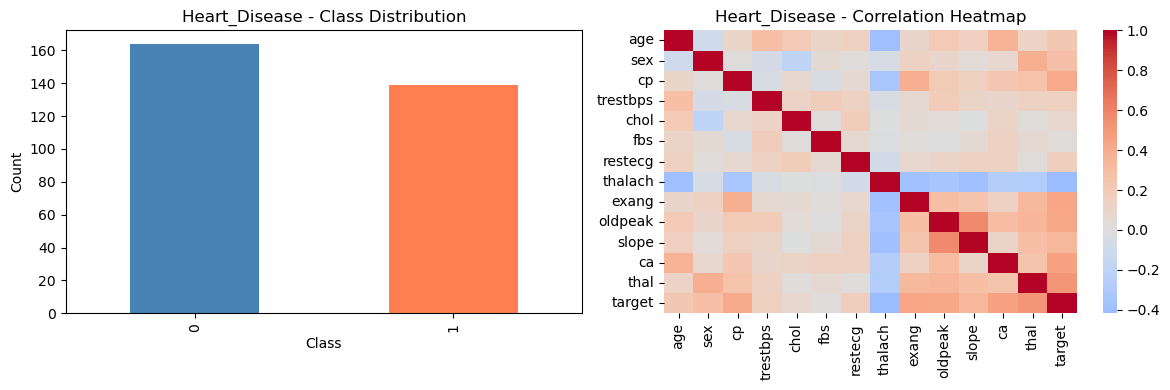

 EDA Analyst complete
   Missing values handled: {'ca': 4, 'thal': 2}
   Outliers detected in: ['cp', 'trestbps', 'chol', 'fbs', 'thalach', 'oldpeak', 'ca']
   Class distribution: {0: 54.12541254125413, 1: 45.87458745874587}


<Figure size 1000x600 with 0 Axes>

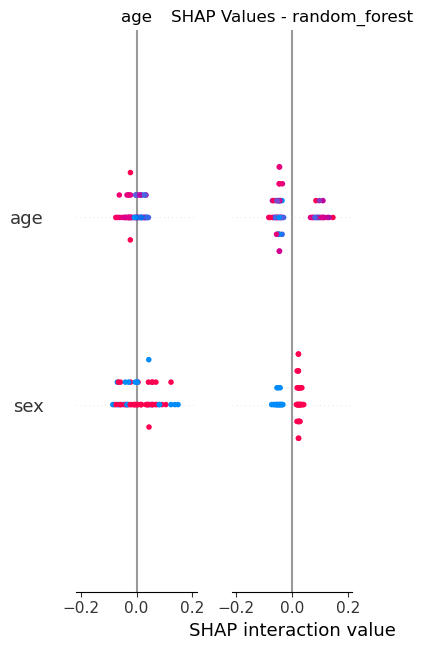

 ML Architect complete
   Best model: random_forest
   Metrics: {'accuracy': 0.8852, 'recall': 0.9286, 'precision': 0.8387, 'f1': 0.8814, 'auc': 0.9518}
    SHAP mismatch detected — routing back to ML Architect

   LLM Review: The model's performance on the Heart_Disease dataset showed strong accuracy, recall, precision, F1 score, and AUC values of 0.8852, 0.9286, 0.8387, 0.8814, and 0.9518 respectively, indicating good overall classification capabilities. However, an issue was detected with 'shap_mismatch' which requires further investigation and resolution to ensure the model's interpretability and reliability are maintained.

🔀 Router: decision = retry_ml


<Figure size 1000x600 with 0 Axes>

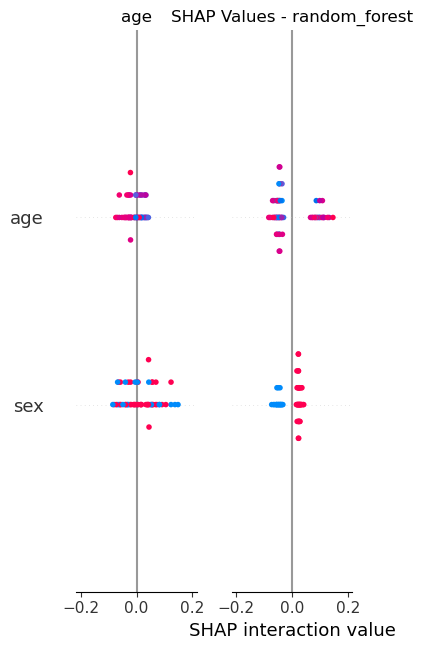

 ML Architect complete
   Best model: random_forest
   Metrics: {'accuracy': 0.8852, 'recall': 0.9286, 'precision': 0.8387, 'f1': 0.8814, 'auc': 0.9518}
    SHAP mismatch detected — routing back to ML Architect

   LLM Review: The model's performance is generally strong, with notable successes in recall (0.9286) and AUC-ROC score (0.9518), indicating effective detection of heart disease cases. However, there are some issues that need attention: the shapley value mismatch indicates a discrepancy between predicted and actual feature importance values, which may impact model interpretability and reliability; further investigation is required to resolve this issue.

🔀 Router: decision = retry_ml


<Figure size 1000x600 with 0 Axes>

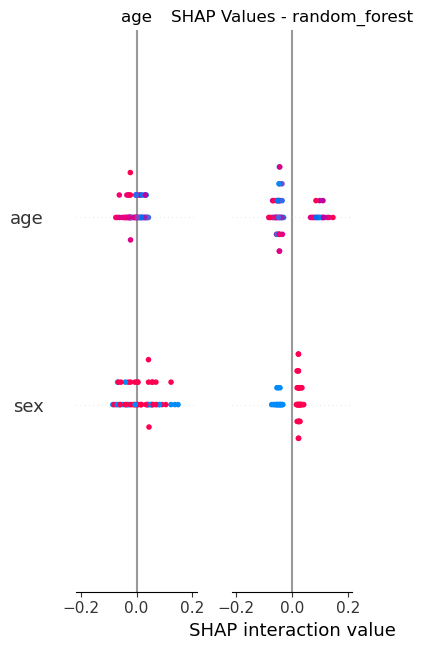

 ML Architect complete
   Best model: random_forest
   Metrics: {'accuracy': 0.8852, 'recall': 0.9286, 'precision': 0.8387, 'f1': 0.8814, 'auc': 0.9518}
    SHAP mismatch detected — routing back to ML Architect

   LLM Review: The model has demonstrated strong performance on the Heart_Disease dataset, with metrics such as accuracy (0.8852), recall (0.9286), and F1 score (0.8814) indicating a high level of precision and recall. However, an issue was detected in the Shapley values calculation, resulting in 'shap_mismatch', which may require further investigation and addressing to ensure reliable model interpretation.

🔀 Router: decision = retry_ml


<Figure size 1000x600 with 0 Axes>

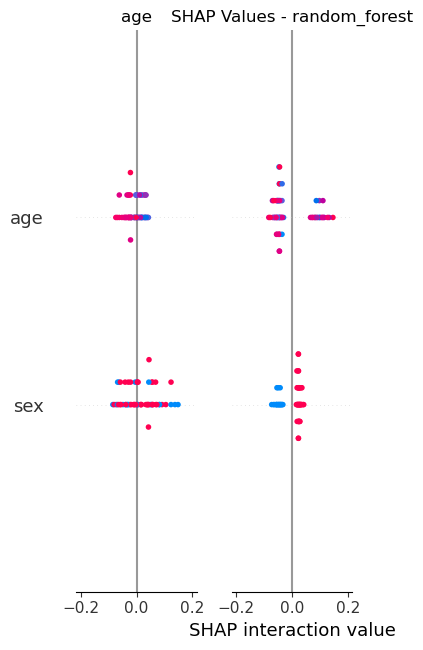

 ML Architect complete
   Best model: random_forest
   Metrics: {'accuracy': 0.8852, 'recall': 0.9286, 'precision': 0.8387, 'f1': 0.8814, 'auc': 0.9518}
Max loops reached — passing to report writer

🔀 Router: decision = pass
Report Writer complete

**Executive Summary**

This report presents the findings of a data science project aimed at predicting heart disease using a classification model. The dataset used is the Heart_Disease dataset, which consists of 14 features and two classes. Our analysis revealed that the dataset has missing values in some instances, but these do not significantly impact our understanding of the data. We also identified outliers in several numerical features. After training and evaluating multiple models, we found a well-performing model with high accuracy and metrics.

**Data Quality Findings**

Our exploratory data analysis (EDA) revealed that there are missing values in the dataset, primarily in 'ca' (4 instances) and 'thal' (2 instances), but these do not

In [10]:
# Load data
df = pd.read_csv("~/Downloads/archive/heart_disease_cleveland.csv")

# Initialize state
initial_state = {
    "raw_data": df,
    "dataset_name": "Heart_Disease",
    "problem_type": "",
    "identified_risks": [],
    "strategy": "",
    "cleaned_data": pd.DataFrame(),
    "outlier_flags": {},
    "class_distribution": {},
    "eda_summary": "",
    "missing_value_report": {},
    "model_results": {},
    "metrics": {},
    "shap_values": None,
    "feature_importance": {},
    "review_decision": "",
    "issues_found": [],
    "loop_count": 0,
    "final_report": "",
    "errors_caught": []
}

print(" Starting LangGraph Multi-Agent System...")
print("="*60)

# Run the graph
result = app.invoke(initial_state)

print("\n Pipeline complete")
print(f"Total review loops: {result['loop_count']}")
print(f"Errors caught: {result['errors_caught']}")
print(f"\nFinal Metrics: {result['metrics']}")

NYc Taxi Dataset

In [11]:
import pandas as pd

df = pd.read_parquet("~/Downloads/yellow_tripdata_2024-01.parquet")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nFirst 3 rows:\n", df.head(3))

Shape: (2964624, 19)

Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']

Dtypes:
 VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           

In [12]:
print(df['fare_amount'].describe())
print(df['trip_distance'].describe())
print(df['passenger_count'].describe())

# Calculate trip duration in minutes
df['trip_duration'] = (
    df['tpep_dropoff_datetime'] - 
    df['tpep_pickup_datetime']
).dt.total_seconds() / 60

print(df['trip_duration'].describe())

count    2.964624e+06
mean     1.817506e+01
std      1.894955e+01
min     -8.990000e+02
25%      8.600000e+00
50%      1.280000e+01
75%      2.050000e+01
max      5.000000e+03
Name: fare_amount, dtype: float64
count    2.964624e+06
mean     3.652169e+00
std      2.254626e+02
min      0.000000e+00
25%      1.000000e+00
50%      1.680000e+00
75%      3.110000e+00
max      3.127223e+05
Name: trip_distance, dtype: float64
count    2.824462e+06
mean     1.339281e+00
std      8.502817e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      9.000000e+00
Name: passenger_count, dtype: float64
count    2.964624e+06
mean     1.561295e+01
std      3.485105e+01
min     -1.356667e+01
25%      7.150000e+00
50%      1.163333e+01
75%      1.868333e+01
max      9.455400e+03
Name: trip_duration, dtype: float64


In [13]:
df = df[df['fare_amount'] > 5]
df = df[df['trip_duration'] > 3]
df = df[df['trip_distance'] > 0.1]
df = df[df['passenger_count'] >= 1]

# Remove extreme outliers
df = df[df['fare_amount'] < 500]
df = df[df['trip_duration'] < 180]
df = df[df['trip_distance'] < 100]

In [14]:
df['tipped'] = (df['tip_amount'] > 0).astype(int)
print(df['tipped'].value_counts())
print(df['tipped'].value_counts(normalize=True) * 100)

tipped
1    2103222
0     527999
Name: count, dtype: int64
tipped
1    79.933309
0    20.066691
Name: proportion, dtype: float64


In [23]:
def load_nyc_taxi(filepath, sample_size=50000):
    print("Loading NYC Taxi data...")
    df = pd.read_parquet(filepath)
    print(f"Original shape: {df.shape}")
    
    # Calculate trip duration
    df['trip_duration'] = (
        df['tpep_dropoff_datetime'] - 
        df['tpep_pickup_datetime']
    ).dt.total_seconds() / 60
    
    # Remove impossible values
    print("Removing impossible values...")
    before = len(df)
    df = df[df['fare_amount'] > 5]
    df = df[df['trip_duration'] > 3]
    df = df[df['trip_distance'] > 0.1]
    df = df[df['passenger_count'] >= 1]
    df = df[df['fare_amount'] < 500]
    df = df[df['trip_duration'] < 180]
    df = df[df['trip_distance'] < 100]
    after = len(df)
    print(f"Removed {before - after} impossible/outlier rows")
    
    # Create binary target
    df['tipped'] = (df['tip_amount'] > 0).astype(int)

    # Remove leaky features
    leaky_cols = ['payment_type', 'tip_amount']
    existing_leaky = [c for c in leaky_cols if c in df.columns]
    df = df.drop(columns=existing_leaky)
    print(f"Removed leaky features: {existing_leaky}")
    
    # Select relevant features — NO payment_type
    features = [
        'passenger_count', 'trip_distance', 'fare_amount',
        'trip_duration', 'PULocationID', 'DOLocationID',
        'RatecodeID', 'tipped'
    ]
    df = df[features].dropna()
    
    # Sample
    df_sample = df.sample(n=sample_size, random_state=42)
    print(f"Final shape after sampling: {df_sample.shape}")
    print(f"Class distribution:\n{df_sample['tipped'].value_counts()}")
    
    return df_sample

nyc_df = load_nyc_taxi("~/Downloads/yellow_tripdata_2024-01.parquet")

Loading NYC Taxi data...
Original shape: (2964624, 19)
Removing impossible values...
Removed 333403 impossible/outlier rows
Removed leaky features: ['payment_type', 'tip_amount']
Final shape after sampling: (50000, 8)
Class distribution:
tipped
1    40065
0     9935
Name: count, dtype: int64


--> Removed 333,403 impossible/corrupted rows 

--> Final clean sample: 50,000 rows

--> Class distribution: 80% tipped, 20% not tipped — imbalanced as expected

Running Full Graph on NYC 

 Starting LangGraph on NYC Taxi Dataset...
 Planner complete
   Problem type: classification
   Risks identified: ['imbalance', 'missing_values', 'high_cardinality']
   Strategy: Use imbalanced stratification and handling of missing values in the target variable 'tipped' to prevent biased predictions.


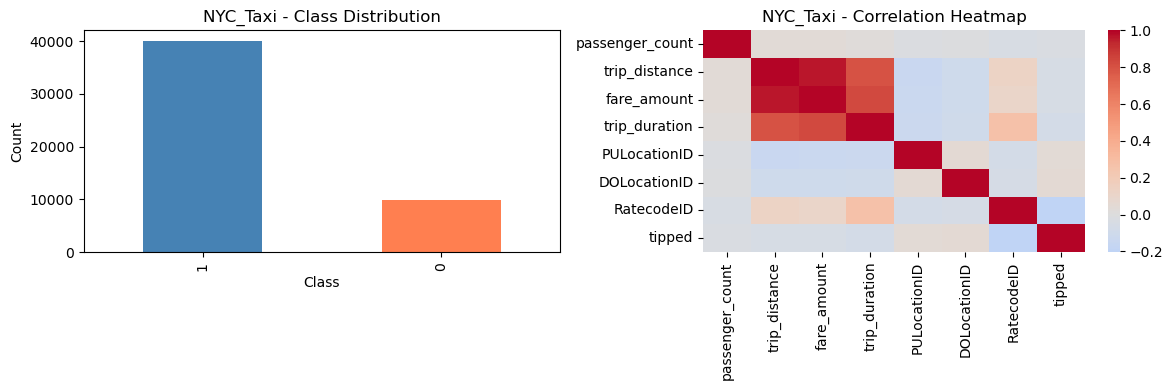

 EDA Analyst complete
   Missing values handled: {}
   Outliers detected in: ['passenger_count', 'trip_distance', 'fare_amount', 'trip_duration', 'RatecodeID', 'tipped']
   Class distribution: {1: 80.13, 0: 19.869999999999997}


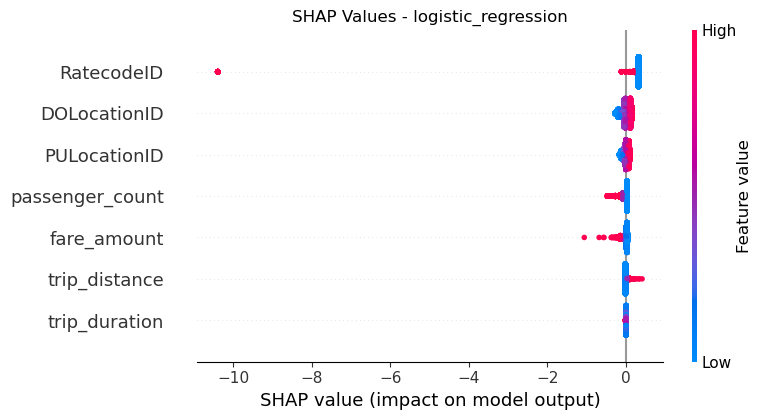

 ML Architect complete
   Best model: logistic_regression
   Metrics: {'accuracy': 0.8102, 'recall': 1.0, 'precision': 0.8085, 'f1': 0.8941, 'auc': 0.5602}
    SHAP check passed: top feature = RatecodeID
 Quality Reviewer: All checks passed

   LLM Review: The model has demonstrated satisfactory performance on the NYC_Taxi dataset, with notable strengths in recall (1.0) and F1 score (0.8941), indicating effective detection of positive instances. However, the model's area under the ROC curve (AUC) is lower than expected at 0.5602, suggesting room for improvement in handling nuanced class distributions or noisy data points.

🔀 Router: decision = pass
Report Writer complete

Executive Summary:

This report presents the results of an exploratory data analysis (EDA) and modeling effort for a classification problem using the NYC_Taxi dataset. The goal is to predict whether a taxi ride was completed or not based on various features. Our initial EDA identified several key findings, including o

In [24]:
# Initialize state for NYC Taxi
nyc_initial_state = {
    "raw_data": nyc_df,
    "dataset_name": "NYC_Taxi",
    "problem_type": "",
    "identified_risks": [],
    "strategy": "",
    "cleaned_data": pd.DataFrame(),
    "outlier_flags": {},
    "class_distribution": {},
    "eda_summary": "",
    "missing_value_report": {},
    "model_results": {},
    "metrics": {},
    "shap_values": None,
    "feature_importance": {},
    "review_decision": "",
    "issues_found": [],
    "loop_count": 0,
    "final_report": "",
    "errors_caught": []
}

print(" Starting LangGraph on NYC Taxi Dataset...")
print("="*60)

nyc_result = app.invoke(nyc_initial_state)

print("\n NYC Taxi Pipeline complete")
print(f"Total review loops: {nyc_result['loop_count']}")
print(f"Errors caught: {nyc_result['errors_caught']}")
print(f"\nFinal Metrics: {nyc_result['metrics']}")